In [2]:
from math import * 
import pandas as pd

X1 = (0, pi/4, pi/2)
Y1 = (sin(0), sin(pi/4), sin(pi/2))
pd.DataFrame([X1,Y1],index=['X','Y'])

,0,1,2
X,0.0,0.785398,1.570796
Y,0.0,0.707107,1.000000


In [3]:
#compresión de listas
l = [i for i in range(0,3)]
print(l)

[0, 1, 2]


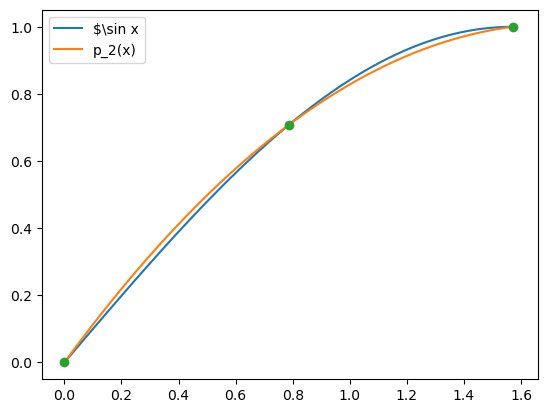

In [4]:
from sympy import *
from sympy.abc import x, epsilon,alpha
import numpy as np
import matplotlib.pyplot as plt

p1 = interpolating_poly(3,x,X1,Y1)  #función de SymPy que interpola un polinomio
p1n = lambdify(x,p1)  #lambdify =(args,expr) convertimos en simbolico una funcion numerica
#def pln(f):
# return numerico
x1r = np.linspace(0,1.58)
plt.plot(x1r,np.sin(x1r),label = r'$\sin x')
plt.plot(x1r, p1n(x1r),label = 'p_2(x)')
plt.plot([x for x in X1],[y for y in Y1],'o')
plt.legend();

In [4]:
def lagrange(xi,X,Y):
    n = len(X)
    p = 0
    for k in range(0,n):
        l = 1
        for j in range(0,n):
            if k != j: #aquí pedimos ortonormalidad
                l*=((xi-X[j]))/(X[k]-X[j])
        p+=Y[k]*l
    return p


lagrange(0.8,X1,Y1)

0.716331012845106

In [5]:
def lagrange2(x,X,Y):
    if len(X)!=len(Y):
        return ('Vectores con dimensiones distintas')
    else:
        Points = list(zip(X,Y)) #aquí genero los puntos, con las listas dadas por el usuario
        Lk = [ ] #aquí guardo los poinomios de Lagrange
        n = len(X)
        for i in range(n): #índice lento
            l = 1
            for k in range(n): #índice rápido
                if k!=i: #ortonormalidad
                    l*=(x-X[k])/float(X[i]-X[k]) #este es el k-esimo polinomio de Lagrange
            Lk.append(l)
        polinomio = 0.0
        for i in range(n):
            polinomio +=Lk[i]*Y[i]
        return polinomio

In [6]:
lagrange2(0.8,X1,Y1)

0.716331012845106

2.2344969487553255 2.2627756906819614


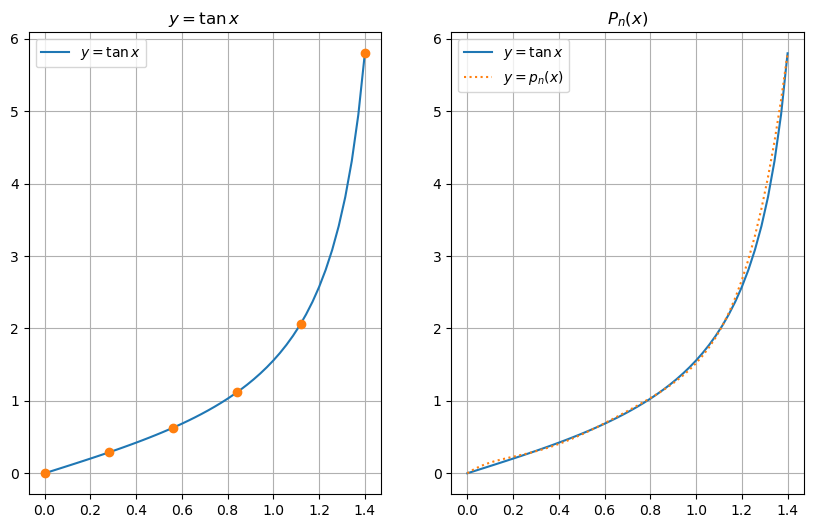

In [7]:
n = 6 #
X2 = np.linspace(0,1.4,n)
Y2 = np.tan(X2) #Las funciones en numby te reciben un arreglo y te regresan un arreglo cuyas entradas son los valores del arreglo original valuados en la función
print(np.tan(1.15),lagrange(1.15,X2,Y2))

fig, (ax1,ax2) = plt.subplots(ncols = 2 , figsize =(10,6))
xr = np.linspace(0,1.4)
ax1.plot(xr,np.tan(xr),label =r"$y = \tan x$")
ax1.plot(X2,Y2,'o')
ax1.set_title(r"$ y = \tan x$")
ax1.legend()
ax1.grid()

xr = np.linspace(0,1.4)
ax2.set_title(r"$P_n(x)$")
ax2.plot(xr,np.tan(xr),label =r"$y = \tan x$")
ax2.plot(xr,lagrange(xr,X2,Y2),':',label = r"$y = p_n(x)$")
ax2.legend()
ax2.grid()


2.2344969487553255 2.2627756906819614


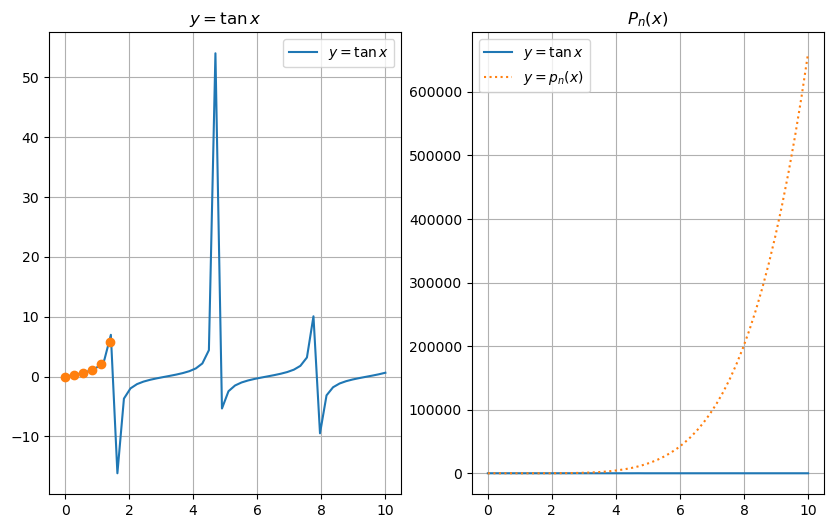

In [8]:
n = 6 #
X2 = np.linspace(0,1.4,n)
Y2 = np.tan(X2)
print(np.tan(1.15),lagrange(1.15,X2,Y2))

fig, (ax1,ax2) = plt.subplots(ncols = 2 , figsize =(10,6))
xr = np.linspace(0,10)
ax1.plot(xr,np.tan(xr),label =r"$y = \tan x$")
ax1.plot(X2,Y2,'o')
ax1.set_title(r"$ y = \tan x$")
ax1.legend()
ax1.grid()

xr = np.linspace(0,10)
ax2.set_title(r"$P_n(x)$")
ax2.plot(xr,np.tan(xr),label =r"$y = \tan x$")
ax2.plot(xr,lagrange(xr,X2,Y2),':',label = r"$y = p_n(x)$")
ax2.legend()
ax2.grid()

## Diferencias Divididas

In [30]:
#Tabla de diferencias divididas
from itertools import zip_longest
X3 = [1 + 0.1*i for i in range(5)]
f_i = [np.cos(X3[i]) for i in range(5)]

f_ii = [(f_i[i+1]-f_i[i])/(X3[i+1]-X3[i]) for i in range(4)] #Diferencia de orden 1
f_iii = [(f_ii[i+1] - f_ii[i])/(X3[i+2]-X3[i]) for i in range(3)] #diferencia ord 2
f_iiii = [(f_iii[i+1] - f_iii[i])/(X3[i+3]-X3[i]) for i in range(2)] #dif ord 3
f_iiiii = [(f_iiii[i+1] - f_iiii[i])/(X3[i+4]-X3[i]) for i in range(1)] #dif ord 4

ffdat = pd.DataFrame(list(zip_longest(f_i,f_ii,f_iii,f_iiii,f_iiiii)),
            index=range(5),columns = ["$f(x_i)$",'$Df(x_i)$','$D^2f(x_i)$','$D^3f(x_i)$','$D^4f(x_i)$'])
ffdat.insert(0,'$x_i$',X3) 
ffdat

,$x_i$,$f(x_i)$,$Df(x_i)$,$D^2f(x_i)$,$D^3f(x_i)$,$D^4f(x_i)$
0,1.0,0.540302,-0.867062,-0.226609,0.151937,0.015073
1,1.1,0.453596,-0.912384,-0.181028,0.157967,NaN
2,1.2,0.362358,-0.948589,-0.133638,NaN,NaN
3,1.3,0.267499,-0.975317,NaN,NaN,NaN
4,1.4,0.169967,NaN,NaN,NaN,NaN


In [31]:
print(f_i)

[0.5403023058681398, 0.4535961214255773, 0.3623577544766736, 0.26749882862458735, 0.16996714290024104]


Obtenemos
\begin{align}
    P_1(x) &= 0.5403 - 0.86706(x-1)\\
    P_2(x) &= P_1(x) - 0.22661(x-1)(x-1.1)\\
    P_3(x) &= P_2(x) + 0.15194(x-1)(x-1.1)(x-1.2)\\
    P_4(x) &= P_3(x) + 0.01507(x-1)(x-1.1)(x-1.2)(x-1.3)\\
\end{align}

In [28]:
X4 = [i for i in range(7)]

f_1 = [X4[i]**3 - 4*X4[i] for i in range(7)]

f_2 = [(f_1[i+1]-f_1[i])/(X4[i+1]-X4[i]) for i in range(6)] #Diferencia de orden 1
f_3 = [(f_2[i+1] - f_2[i])/(X4[i+2]-X4[i]) for i in range(5)] #diferencia ord 2
f_4 = [(f_3[i+1] - f_3[i])/(X4[i+3]-X4[i]) for i in range(4)] #dif ord 3
f_5 = [(f_4[i+1] - f_4[i])/(X4[i+4]-X4[i]) for i in range(3)] #dif ord 4
f_6 = [(f_5[i+1] - f_5[i])/(X4[i+5]-X4[i]) for i in range(2)]
f_7 = [(f_6[i+1] - f_6[i])/(X4[i+6]-X4[i]) for i in range(1)]

ffdat = pd.DataFrame(list(zip_longest(f_1,f_2,f_3,f_4,f_5,f_6,f_7)),
            index=range(7),columns = ["$f(x_i)$",'$Df(x_i)$','$D^2f(x_i)$','$D^3f(x_i)$','$D^4f(x_i)$','$D^5f(x_i)$','$D^6f(x_i)$'])
ffdat.insert(0,'$x_i$',X4) 
ffdat


,$x_i$,$f(x_i)$,$Df(x_i)$,$D^2f(x_i)$,$D^3f(x_i)$,$D^4f(x_i)$,$D^5f(x_i)$,$D^6f(x_i)$
0,0,0,-3.0,3.0,1.0,0.0,0.0,0.0
1,1,-3,3.0,6.0,1.0,0.0,0.0,NaN
2,2,0,15.0,9.0,1.0,0.0,NaN,NaN
3,3,15,33.0,12.0,1.0,NaN,NaN,NaN
4,4,48,57.0,15.0,NaN,NaN,NaN,NaN
5,5,105,87.0,NaN,NaN,NaN,NaN,NaN
6,6,192,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
x = 1.05
exacto = np.cos(x)
print('{:10.8e}'.format(exacto)) #equivaente a print('%10.8f'%exacto)

P = {}
#Extraer el primer renglon de la tabla vive en pandas
r0 = ffdat.iloc(0)[0]

P[1] = r0[1] + r0[2]*(x-1)
P[2] = P[1] + r0[3]*(x-1)*(x-1.1)
P[3] = P[2] + r0[4]*(x-1)*(x-1.1)*(x-1.2)
P[4] = P[3] + r0[5]*(x-1)*(x-1.1)*(x-1.2)*(x-1.3)

PE = dict([(i,exacto-P[i]) for i in range(1,5)])
pd.DataFrame([P,PE],index = ['$P_n(x)$','Error'])

4.97571048e-01


,1,2,3,4
$P_n(x)$,0.496949,0.497516,0.497573,4.975713e-01
Error,0.000622,0.000055,-0.000002,-2.519410e-07
